# MCAR PolyMNIST

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import numpy as np

## Coherences

In [9]:
table = pd.read_csv('./results/results.csv')


In [12]:
table_coherences = table.melt(id_vars=['model_name','missing_ratio', 'keep_incomplete'], value_vars=[f'mean_coherence_{i}' for i in range(1,5)], var_name='inputs_mods', value_name='coherence')
table_coherences['inputs_mods'] = table_coherences['inputs_mods'].apply(lambda x: x.split('_')[-1])
table_coherences.replace('JNFDcca', 'JNF-Shared', inplace=True)

/Users/agathe/dev/multivae_package/venv/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 590.551x196.85 with 0 Axes>

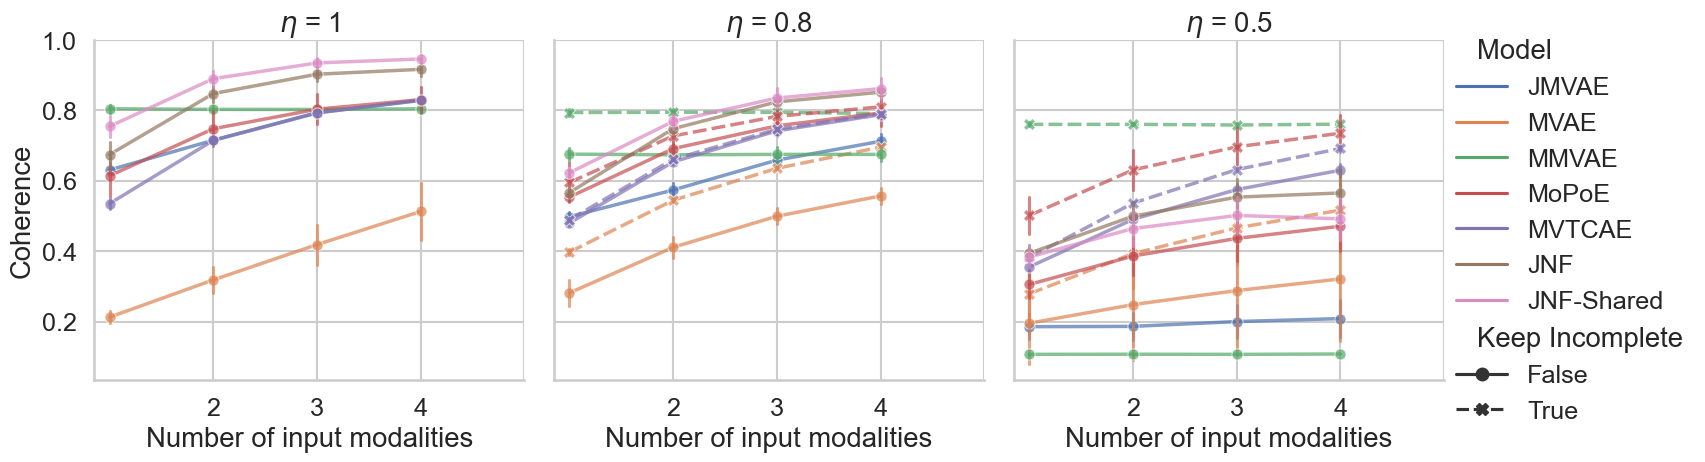

In [14]:
sb.set_theme(style="whitegrid")
sb.set_context('talk',font_scale=1.1)
cm = 1/2.54  # centimeters in inches
plt.figure(figsize=(15*cm,5*cm))

table_coherences = table_coherences.rename(columns={'keep_incomplete' : 'Keep Incomplete','model_name':'Model'})

a = sb.relplot(
    data=table_coherences,
    x='inputs_mods',
    y='coherence',
    col='missing_ratio',
    style='Keep Incomplete',
    hue='Model',
    hue_order=['JMVAE','MVAE','MMVAE','MoPoE','MVTCAE','JNF','JNF-Shared'],
    kind='line',
    errorbar = 'sd',
    err_style = 'bars', 
    alpha = 0.7,
    markers=True,
    linewidth=2.5,
    markersize=8,
    )
    
a.axes[0][0].set_title(r'$\eta$ = 1')
a.axes[0][1].set_title(r'$\eta$ = 0.8')
a.axes[0][2].set_title(r'$\eta$ = 0.5')

a.axes[0][0].set_ylabel('Coherence')
a.axes[0][0].set_xlabel('Number of input modalities')
a.axes[0][1].set_xlabel('Number of input modalities')
a.axes[0][2].set_xlabel('Number of input modalities')

a.axes[0][0].set_xticks([1,2,3,4])
a.axes[0][1].set_xticks([1,2,3,4])
a.axes[0][2].set_xticks([1,2,3,4])

# a.legend.remove()

# plt.savefig('Coherences.svg')


## Clustering in the joint space 

In [ ]:
table_k = pd.read_csv('./results/kmeans.csv')
table_k = table_k.rename(columns={'keep_incomplete' : 'Keep Incomplete',
                             'cluster_accuracy' : 'Accuracy'})
table_k = table_k.replace({'JNFDcca':'JNF-Shared'})



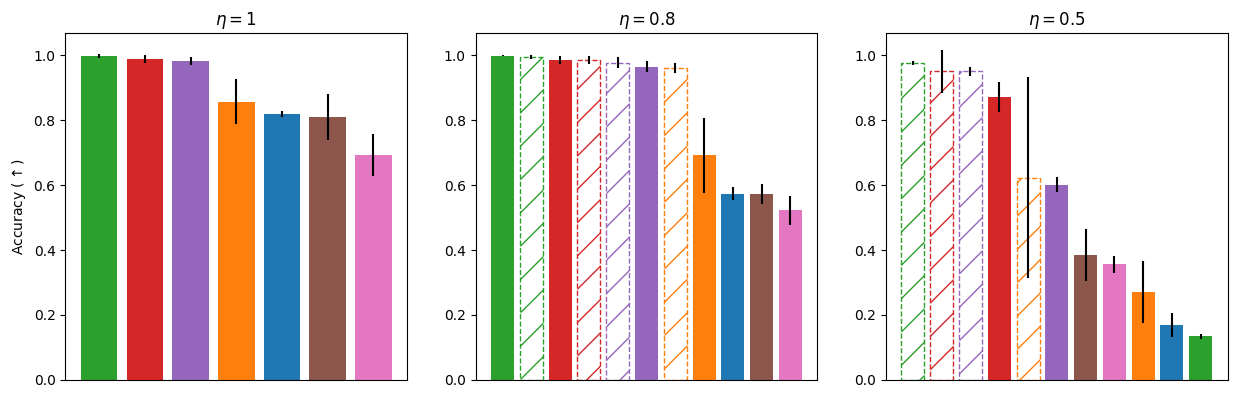

In [8]:

t0 = table_k.sort_values(by=['Accuracy'], ascending=False)

plt.figure(figsize=(15,4.5))

# Create a barplot where the color of the bar is the same as in the lineplot above
color_mapping = {'JMVAE': sb.color_palette()[0],
                                           'MVAE': sb.color_palette()[1],
                                           'MMVAE': sb.color_palette()[2],
                                           'MoPoE': sb.color_palette()[3],
                                           'MVTCAE': sb.color_palette()[4],
                                           'JNF': sb.color_palette()[5],
                                           'JNF-Shared': sb.color_palette()[6]}


ax1 = plt.subplot(1,3,1)
# plot the bars for missing_ratio = 0.0
values = t0[t0['missing_ratio'] == 0.0].groupby('model_name')['Accuracy'].mean()
std = t0[t0['missing_ratio'] == 0.0].groupby('model_name')['Accuracy'].std()
order = np.argsort(values)[::-1]
colors = [color_mapping[values.index[i]] for i in order]
plt.bar(np.arange(len(order)),values[order],yerr=std[order],color=colors)
plt.ylabel(r'Accuracy $(\uparrow)$')
plt.xticks([])
plt.title(r'$\eta = 1$')

ax2 = plt.subplot(1,3,2,sharey=ax1)
# plot the bars for missing_ratio = 0.2t
values = t0[(t0['missing_ratio'] == 0.2)].groupby(['model_name','Keep Incomplete']).Accuracy.mean()
std = t0[(t0['missing_ratio'] == 0.2)].groupby(['model_name','Keep Incomplete']).Accuracy.std()
order = np.argsort(values)[::-1]
colors = [color_mapping[values.index[i][0]] for i in order]

keep_incomplete = np.array([values.index[i][1] for i in order],dtype=bool)

plt.bar(np.arange(len(order))[keep_incomplete],
        np.array(values)[order][keep_incomplete],
        yerr=np.array(std)[order][keep_incomplete],
        edgecolor=np.array(colors)[keep_incomplete],
        facecolor='white',
        linestyle='--',
        hatch='/'
        )
plt.bar(np.arange(len(order))[~keep_incomplete],
        np.array(values)[order][~keep_incomplete],
        yerr=np.array(std)[order][~keep_incomplete],
        color=np.array(colors)[~keep_incomplete]
       
        )
plt.xticks([])

plt.title(r'$\eta = 0.8$')


ax3 = plt.subplot(1,3,3,sharey=ax1)
# plot the bars for missing_ratio = 0.5
values = t0[(t0['missing_ratio'] == 0.5)].groupby(['model_name','Keep Incomplete']).Accuracy.mean()
std = t0[(t0['missing_ratio'] == 0.5)].groupby(['model_name','Keep Incomplete']).Accuracy.std()
order = np.argsort(values)[::-1]
colors = [color_mapping[values.index[i][0]] for i in order]

keep_incomplete = np.array([values.index[i][1] for i in order],dtype=bool)

plt.bar(np.arange(len(order))[keep_incomplete],
        np.array(values)[order][keep_incomplete],
        yerr=np.array(std)[order][keep_incomplete],
        edgecolor=np.array(colors)[keep_incomplete],
        facecolor='white',
        linestyle='--',
        hatch='/'
        )
plt.bar(np.arange(len(order))[~keep_incomplete],
        np.array(values)[order][~keep_incomplete],
        yerr=np.array(std)[order][~keep_incomplete],
        color=np.array(colors)[~keep_incomplete]
       
        )
plt.xticks([])

plt.title(r'$\eta = 0.5$')
plt.savefig('accuracy_bars_mmnist.svg')

## FID values

In [30]:
table = pd.read_csv('./results/all_fids.csv')
table = table.replace({'JNFDcca':'JNF-Shared'})

subsets = ["[\'m1\']","[\'m1\', \'m2\']","[\'m1\', \'m2\', \'m3\']","[\'m1\', \'m2\', \'m3\', \'m4\']"]

table = table.melt(
    id_vars=['Model','missing_ratio', 'keep_incomplete'], 
    value_vars=[f'Conditional FD from {s} to m0' for s in subsets], 
    var_name='inputs_mods', 
    value_name='FID'
)
table['inputs_mods'] = table['inputs_mods'].apply(lambda x: x.split(' from ')[1].split(' to ')[0])


/Users/agathe/dev/multivae_package/venv/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


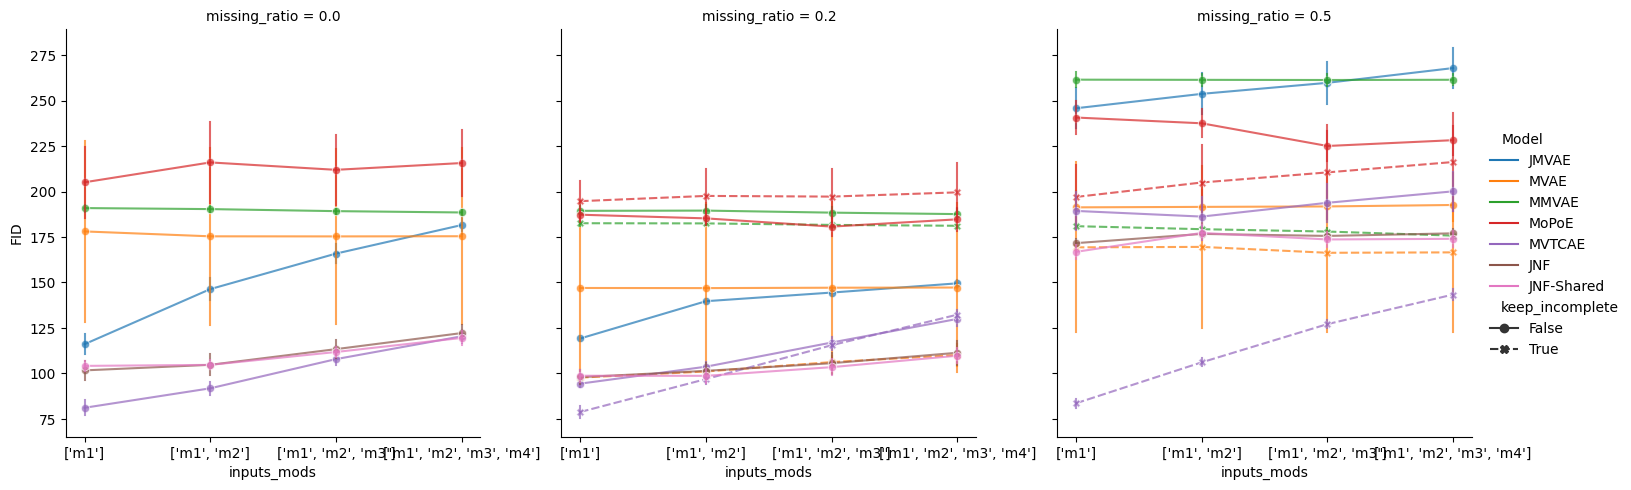

In [31]:
a = sb.relplot(
    data=table,
    x='inputs_mods',
    y='FID',
    col='missing_ratio',
    style='keep_incomplete',
    hue='Model',
    hue_order=['JMVAE','MVAE','MMVAE','MoPoE','MVTCAE','JNF','JNF-Shared'],
    kind='line',
    errorbar = 'se',
    err_style = 'bars',
    markers=True, 
    alpha=0.7,
    
    
    
)

Text(0.5, 1.0, '$\\eta = 0.5$')

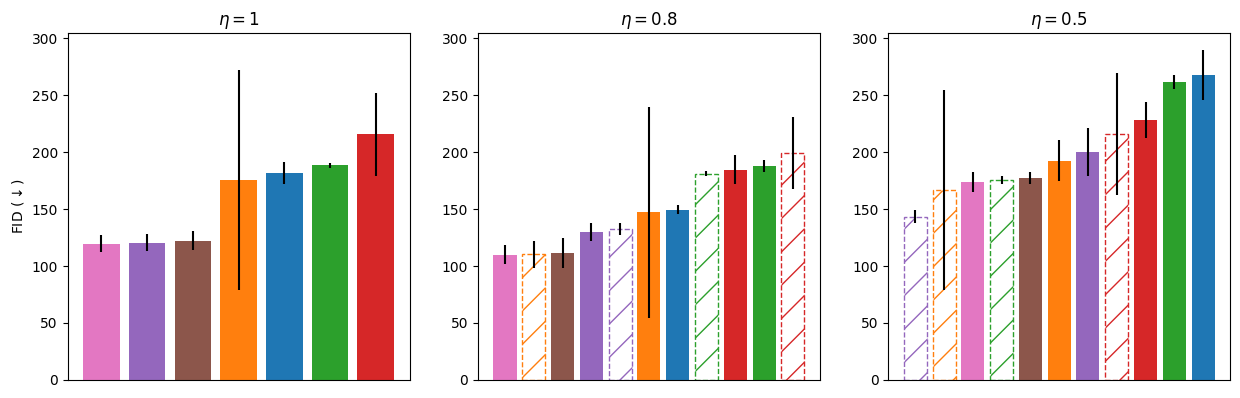

In [32]:
t0 = table[(table['inputs_mods'] == subsets[-1])]
t0 = t0.sort_values(by=['FID'])
t0 = t0.rename(columns={'keep_incomplete' : 'Keep Incomplete'})

plt.figure(figsize=(15,4.5))

# Create a barplot where the color of the bar is the same as in the lineplot above
color_mapping = {'JMVAE': sb.color_palette()[0],
                                           'MVAE': sb.color_palette()[1],
                                           'MMVAE': sb.color_palette()[2],
                                           'MoPoE': sb.color_palette()[3],
                                           'MVTCAE': sb.color_palette()[4],
                                           'JNF': sb.color_palette()[5],
                                           'JNF-Shared': sb.color_palette()[6]}


ax1 = plt.subplot(1,3,1)
# plot the bars for missing_ratio = 0.0
values = t0[t0['missing_ratio'] == 0.0].groupby('Model')['FID'].mean()
std = t0[t0['missing_ratio'] == 0.0].groupby('Model')['FID'].std()
order = np.argsort(values)
colors = [color_mapping[values.index[i]] for i in order]
plt.bar(np.arange(len(order)),values[order],yerr=std[order],color=colors)
plt.ylabel(r'FID $(\downarrow)$')
plt.xticks([])
plt.title(r'$\eta = 1$')

ax2 = plt.subplot(1,3,2,sharey=ax1)
# plot the bars for missing_ratio = 0.2t
values = t0[(t0['missing_ratio'] == 0.2)].groupby(['Model','Keep Incomplete']).FID.mean()
std = t0[(t0['missing_ratio'] == 0.2)].groupby(['Model','Keep Incomplete']).FID.std()
order = np.argsort(values)
colors = [color_mapping[values.index[i][0]] for i in order]

keep_incomplete = np.array([values.index[i][1] for i in order],dtype=bool)

plt.bar(np.arange(len(order))[keep_incomplete],
        np.array(values)[order][keep_incomplete],
        yerr=np.array(std)[order][keep_incomplete],
        edgecolor=np.array(colors)[keep_incomplete],
        facecolor='white',
        linestyle='--',
        hatch='/'
        )
plt.bar(np.arange(len(order))[~keep_incomplete],
        np.array(values)[order][~keep_incomplete],
        yerr=np.array(std)[order][~keep_incomplete],
        color=np.array(colors)[~keep_incomplete]
       
        )
plt.xticks([])

plt.title(r'$\eta = 0.8$')


ax3 = plt.subplot(1,3,3,sharey=ax1)
# plot the bars for missing_ratio = 0.5
values = t0[(t0['missing_ratio'] == 0.5)].groupby(['Model','Keep Incomplete']).FID.mean()
std = t0[(t0['missing_ratio'] == 0.5)].groupby(['Model','Keep Incomplete']).FID.std()
order = np.argsort(values)
colors = [color_mapping[values.index[i][0]] for i in order]

keep_incomplete = np.array([values.index[i][1] for i in order],dtype=bool)

plt.bar(np.arange(len(order))[keep_incomplete],
        np.array(values)[order][keep_incomplete],
        yerr=np.array(std)[order][keep_incomplete],
        edgecolor=np.array(colors)[keep_incomplete],
        facecolor='white',
        linestyle='--',
        hatch='/'
        )
plt.bar(np.arange(len(order))[~keep_incomplete],
        np.array(values)[order][~keep_incomplete],
        yerr=np.array(std)[order][~keep_incomplete],
        color=np.array(colors)[~keep_incomplete]
       
        )
plt.xticks([])

plt.title(r'$\eta = 0.5$')
# plt.savefig('fids_bars_mmnist.svg')